In [353]:
import sys
sys.path.append("..")
import os
print(os.listdir(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import src.preprocessing
importlib.reload(src.preprocessing)
import src.models
importlib.reload(src.models)
from src.preprocessing import read_data, plot_city, split_data, first_changes, change_units, adjust_low_prices, choose_thresholds, normalize_test, normalize_train, one_hot_encoder_tipo
from src.models import LinearRegression, denormalize_dataset

['.git', 'data', 'notebooks', 'README.md', 'requirements.txt', 'src']


In [354]:
data_train, data_test = read_data("../data/raw/casas_dev.csv", "../data/raw/casas_test.csv")
partition = data_train.sample(100)

print(partition)
print(partition.describe())
print(data_train.info())
print(partition.isna().sum())

             precio   tipo        Área  metros_cubiertos unidades  ambientes  \
924   145428.350171  depto  709.028587        694.260451     sqft          7   
317   227156.213727  depto  817.879405        815.922514     sqft         10   
1248   10640.691485  depto   76.021964         73.324556       m2          8   
439        0.000000   casa  248.049791        193.382459       m2         10   
1220  157883.919787  depto  731.892585        723.785716     sqft          3   
...             ...    ...         ...               ...      ...        ...   
866   127420.161362  depto  824.943200        784.983511     sqft          5   
1056  198884.781839  depto  687.954328        686.420394     sqft          6   
437    37929.814119   casa  213.335367        137.829611       m2          4   
1187    7177.606128   casa  204.011061        143.041902       m2         10   
760    34673.057784   casa  192.119881        111.814677       m2          6   

      pisos  pileta        lat        l

From an initial sample of 100 observations, cases of properties with zero price values and missing data in the floors and age columns were identified. Regarding price, values equal to zero would directly mislead the model, and there is no clear way to estimate them, so these observations will be removed from the dataset. For the number of floors, it will be evaluated based on two factors: the type of property and its price. Finally, for the age variable, the mean value of the column will be calculated and used to replace missing data.

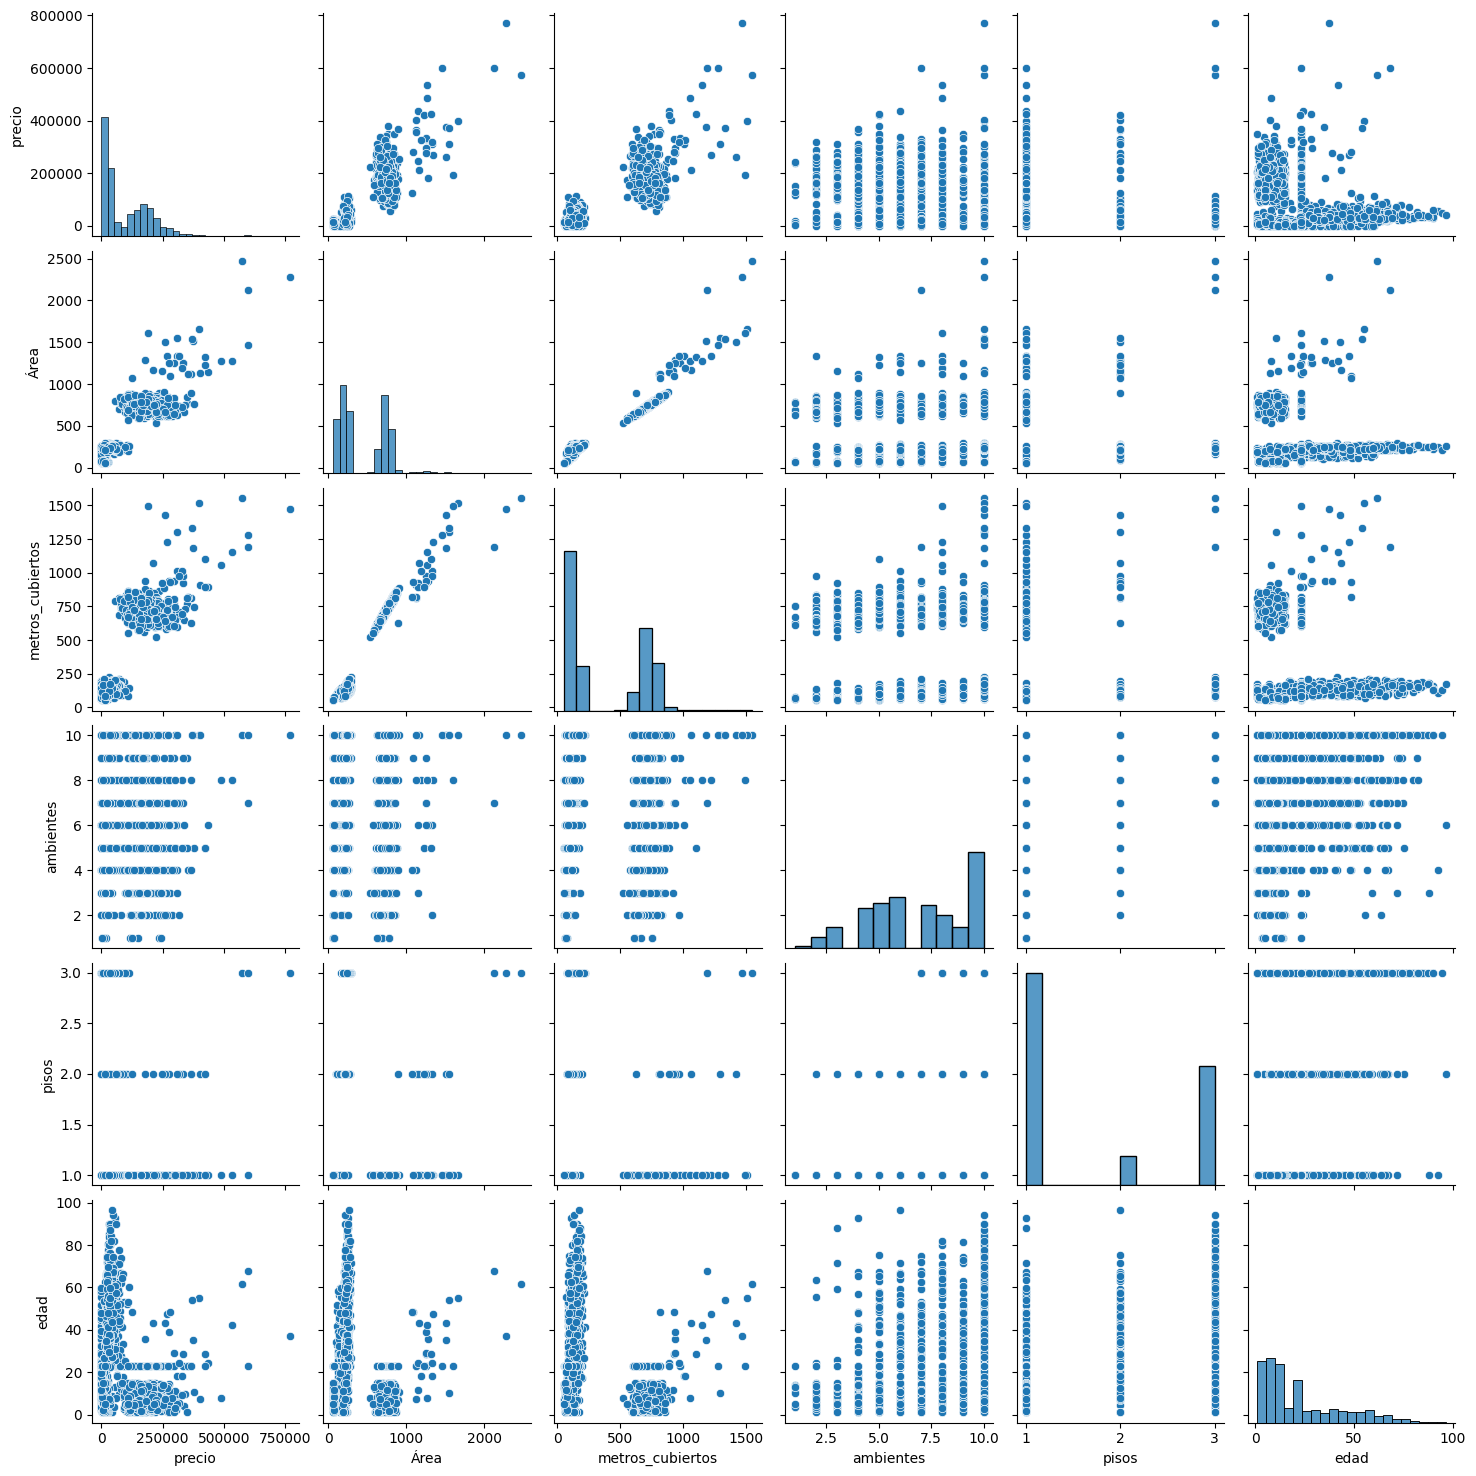

In [355]:
data_train = first_changes(data_train)
data_test = first_changes(data_test)

analisis_features = ["precio", "Área", "metros_cubiertos", "ambientes", "pisos", "edad"]
sns.pairplot(data_train[analisis_features])
plt.show()


From the analysis of the histograms and scatter plots, no strong conclusions can be drawn regarding the distributions or correlations of the variables. Therefore, it will be necessary to apply transformations to better understand the behavior of the features and to facilitate the identification of potential outliers.
A positive trend can be observed in the scatter plot of price versus covered area, suggesting a linear relationship between these variables. In contrast, the relationship between price and total area appears more dispersed, indicating that covered area may be a more consistent predictor of price. Other variables, such as number of rooms and floors, display discrete patterns in the scatter plots, forming vertical groupings rather than continuous relationships. This suggests that their impact on price may not be strictly linear. Additionally, the age variable shows a high concentration of lower values with a long tail, indicating a skewed distribution that may not contribute strongly to linear patterns without transformation.
Overall, several features exhibit skewed or irregular distributions, as observed in the histograms, supporting the use of logarithmic transformations to stabilize variance and improve interpretability.

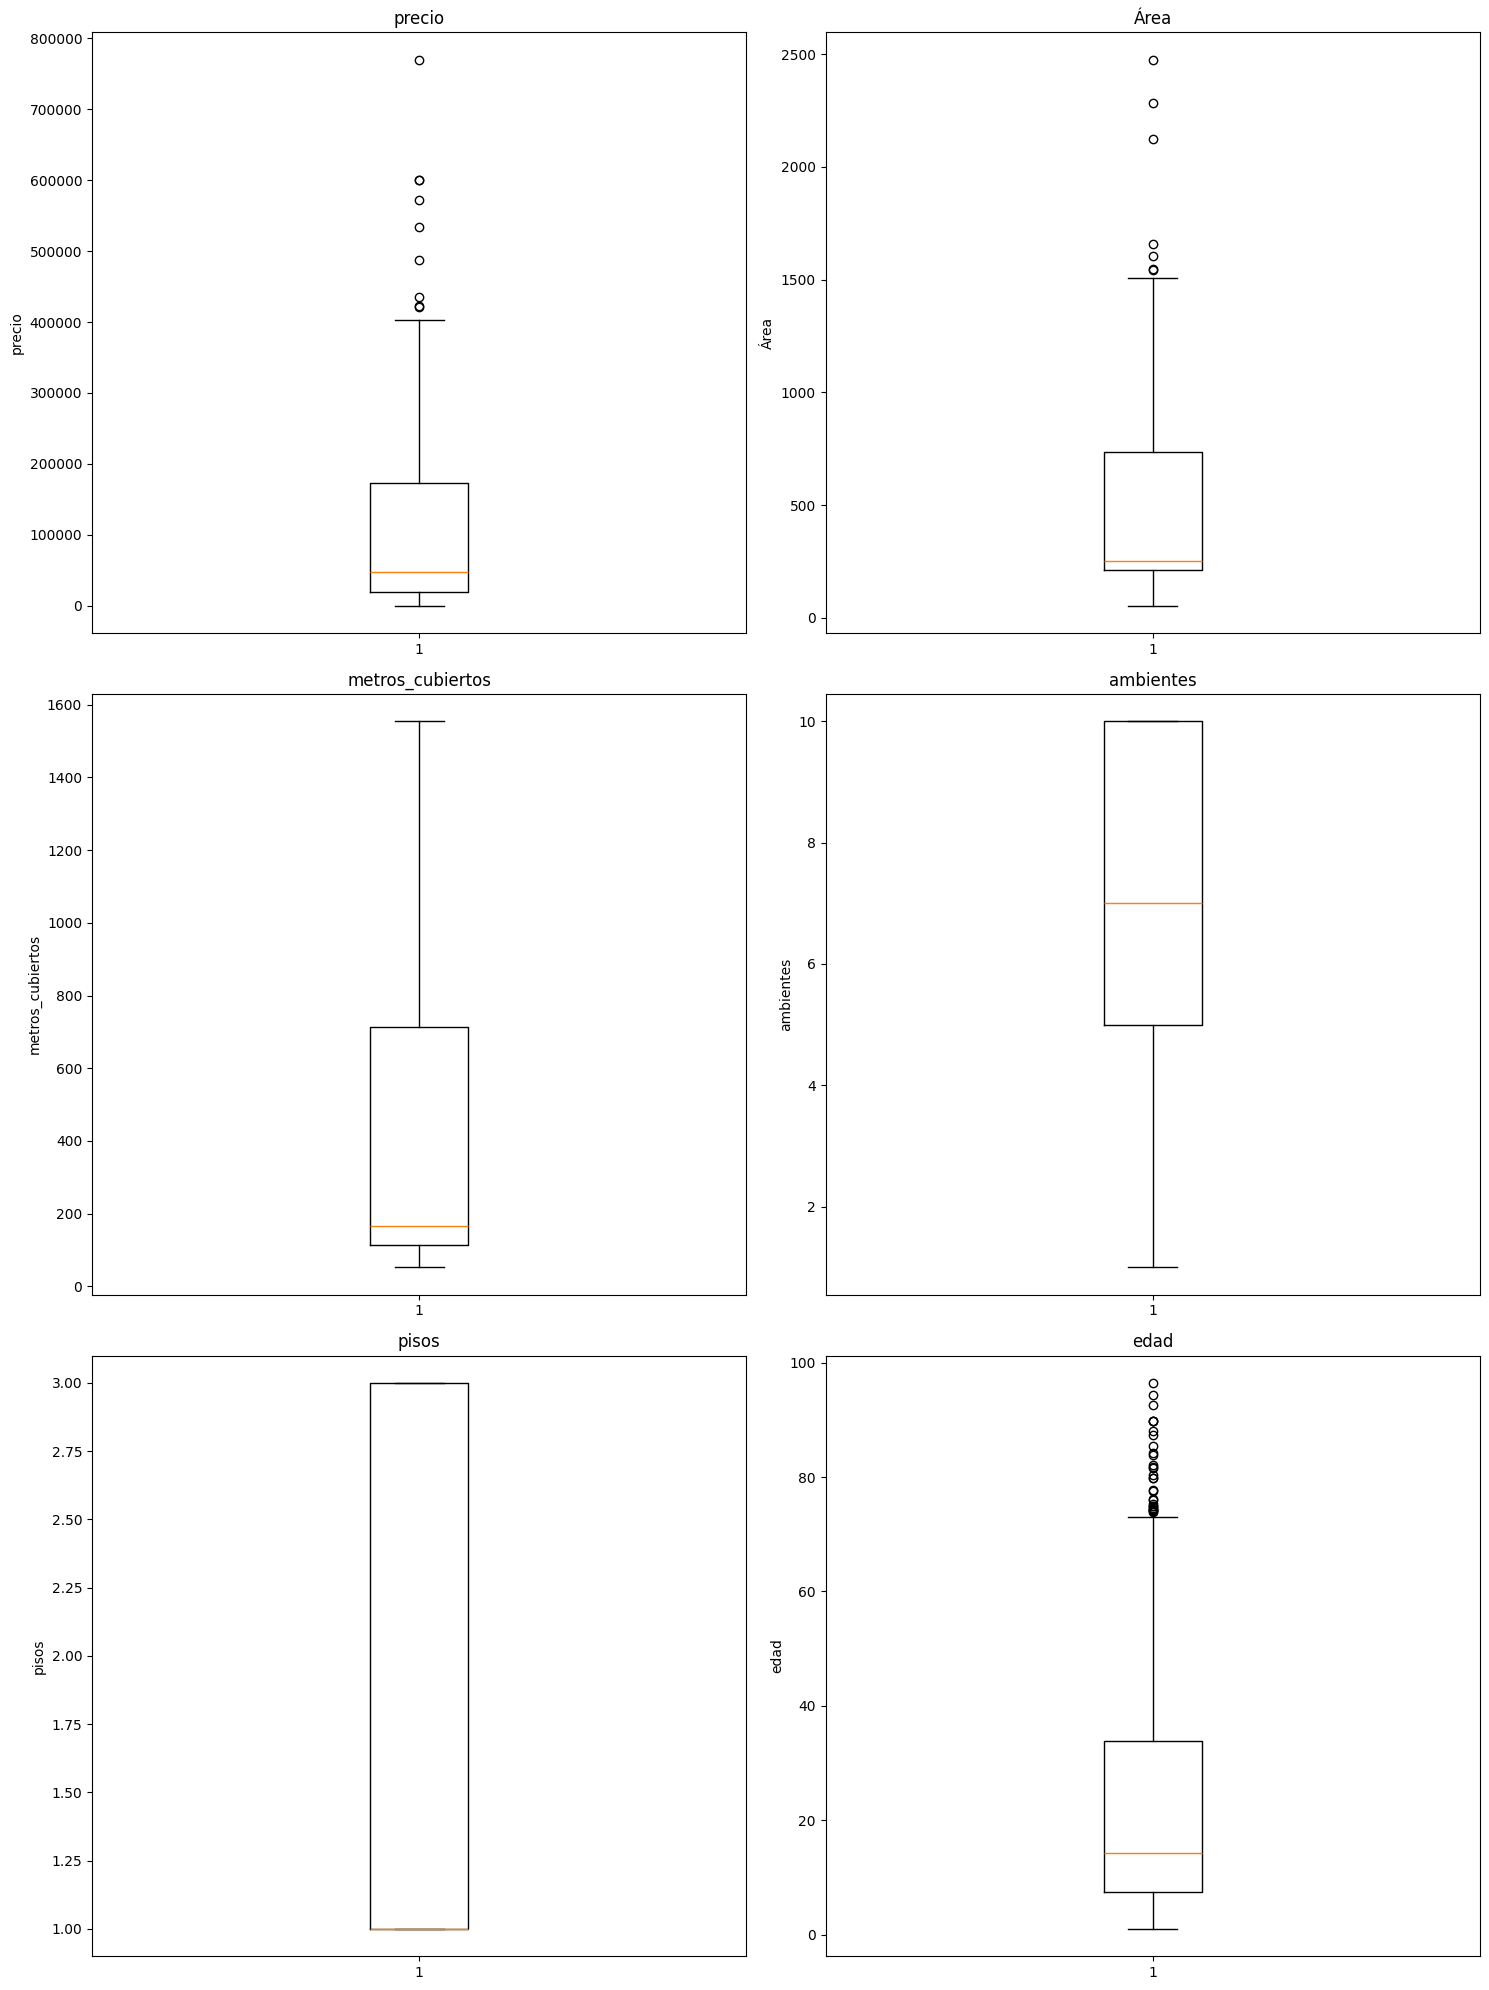

In [356]:
n_features = len(analisis_features)
n_cols = 2
n_rows = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 20))
axes = axes.ravel()

for i, feature in enumerate(analisis_features):
    axes[i].boxplot(data_train[feature].dropna())
    axes[i].set_title(feature)
    axes[i].set_ylabel(feature)


plt.tight_layout()
plt.show()

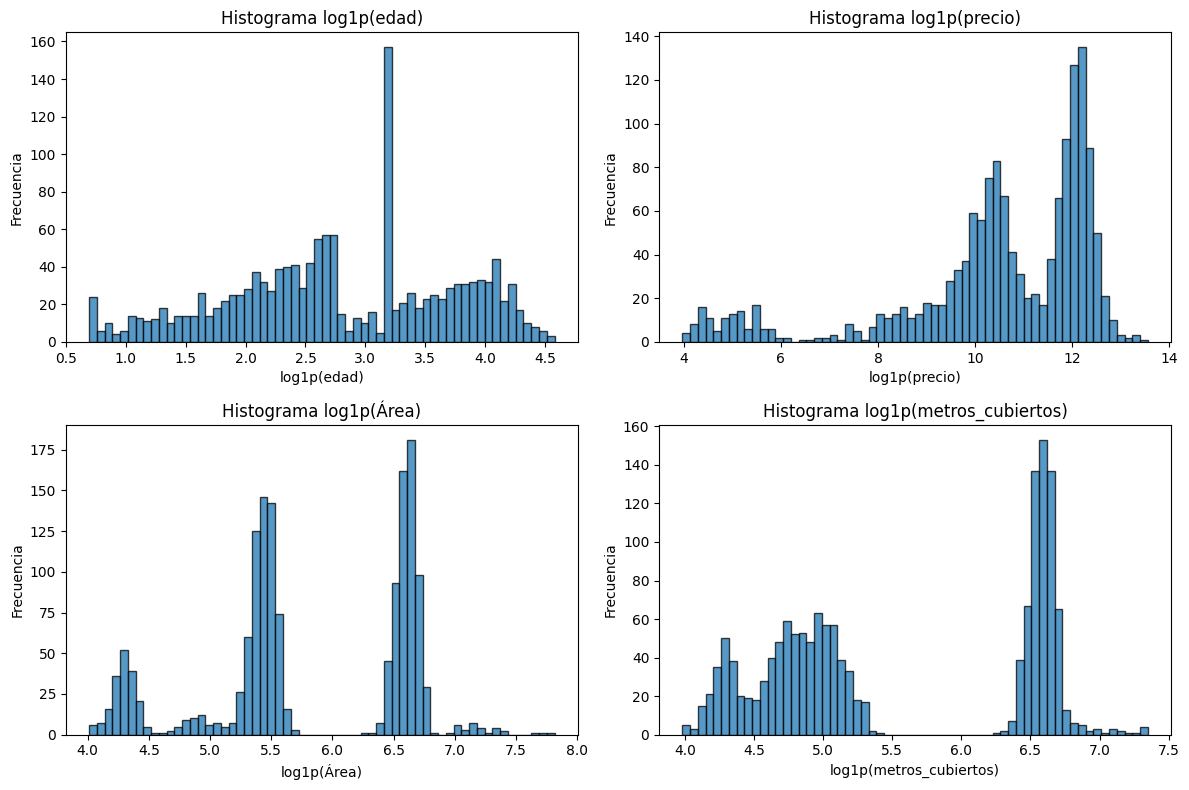

In [357]:
hist_features = ["edad", "precio", "Área", "metros_cubiertos"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, feature in enumerate(hist_features):
    values = data_train[feature].dropna()
    log_values = np.log1p(values)
    axes[i].hist(log_values, bins=60, edgecolor="black", alpha=0.75)
    axes[i].set_title(f"Histograma log1p({feature})")
    axes[i].set_xlabel(f"log1p({feature})")
    axes[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

A logarithmic transformation was applied to continuous variables with the aim of reducing skewness and stabilizing variance. However, the histograms do not show a significant improvement after the transformation, as they still present irregular distributions.
It can also be observed that in variables such as Area and covered surface, multiple peaks persist in the distribution, suggesting the presence of subgroups within the dataset. Price also shows several peaks, indicating that, similar to area, it may follow multiple underlying distributions. In the case of age, the transformation does not lead to a clear improvement either, as the distribution remains uneven and exhibits concentrated regions, suggesting that this variable may not follow a well-behaved continuous pattern.
As no clear patterns are observed, there is limited evidence to draw strong conclusions regarding the presence of outliers. While the boxplots indicate values lying beyond 1.5 times the interquartile range, it cannot be conclusively determined that these values are true outliers, given the lack of clear understanding of the underlying feature distributions.

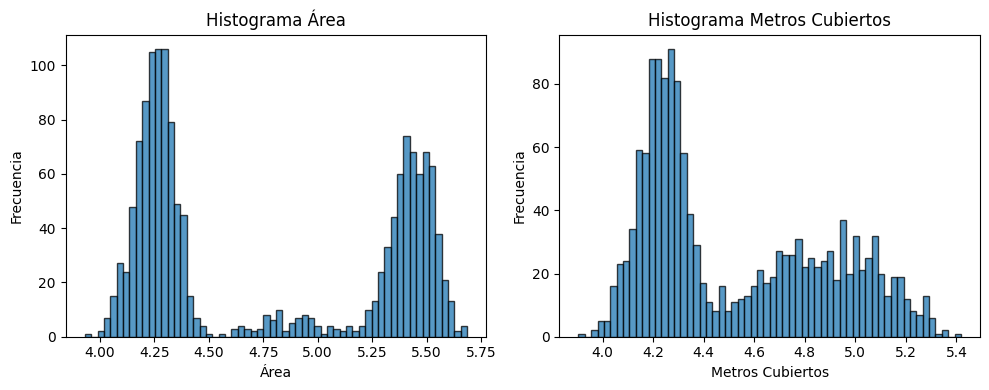

In [358]:
data_train = change_units(data_train)
data_test = change_units(data_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
valueA = np.log1p(data_train["Área"].dropna())
valueM = np.log1p(data_train["metros_cubiertos"].dropna())

axes[0].hist(valueA, bins=60, edgecolor="black", alpha=0.75)
axes[0].set_title("Histograma Área")
axes[0].set_xlabel("Área")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(valueM, bins=60, edgecolor="black", alpha=0.75)
axes[1].set_title("Histograma Metros Cubiertos")
axes[1].set_xlabel("Metros Cubiertos")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

After converting all values to square meters, the distributions of area and covered area remain irregular and exhibit multiple peaks. This indicates that the issue is not related to inconsistent units, but rather to the presence of different subgroups within the dataset.

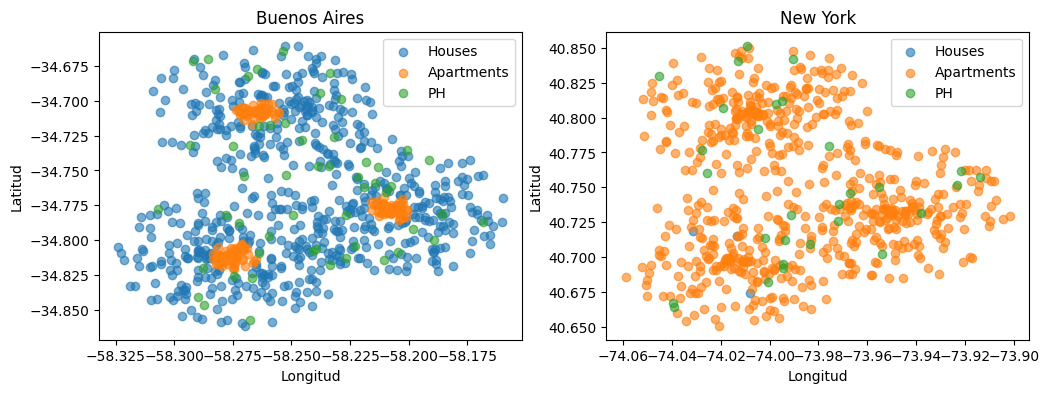

In [359]:
houses = data_train[data_train['tipo'] == 'casa']
apts = data_train[data_train['tipo'] == 'depto']
ph = data_train[data_train['tipo'] == 'ph']

housesBA = houses[houses["lat"] < 0]
aptsBA = apts[apts["lat"] < 0]
phBA = ph[ph["lat"] < 0]

housesNY = houses[houses["lat"] > 0]
aptsNY = apts[apts["lat"] > 0]
phNY = ph[ph["lat"] > 0]

plot_city(housesBA, aptsBA, phBA, housesNY, aptsNY, phNY, "Buenos Aires", "New York")

After segmenting the dataset by location, it becomes evident that New York is predominantly composed of apartments, while Buenos Aires contains a higher proportion of houses. This structural difference helps explain the multiple peaks observed in the distributions of both area and covered surface.
In particular, houses tend to have larger areas compared to apartments, which contributes to the separation of the data into distinct clusters. As a result, when both cities are analyzed together, the combined distribution appears irregular and multimodal rather than following a single pattern. The same seems to happen to the price variable, where the presence of different markets leads to a mixed distribution. Therefore, location and property type play a key role in shaping the behavior of the dataset and should be explicitly considered in the modeling process.

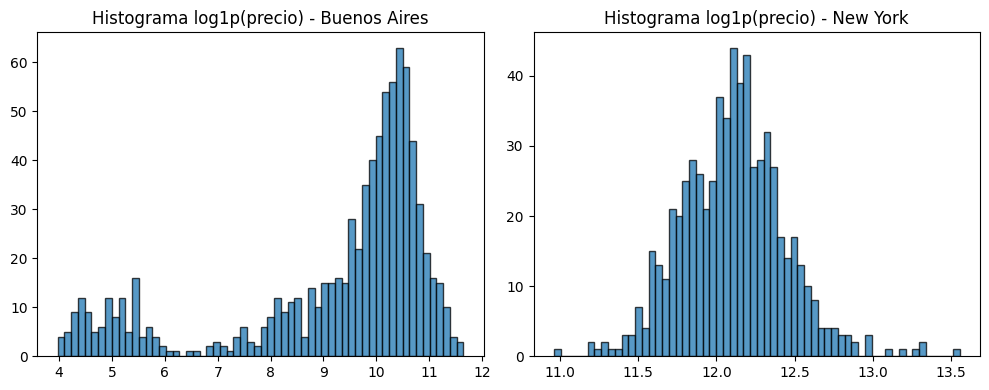

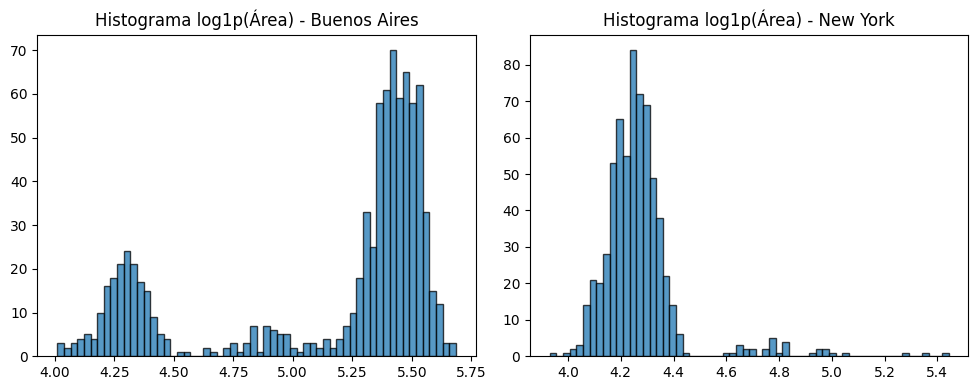

In [360]:
preciosBA = data_train[data_train["lat"] < 0]["precio"]
preciosNY = data_train[data_train["lat"] > 0]["precio"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(np.log1p(preciosBA), bins=60, edgecolor="black", alpha=0.75)
axes[0].set_title("Histograma log1p(precio) - Buenos Aires")
axes[1].hist(np.log1p(preciosNY), bins=60, edgecolor="black", alpha=0.75)
axes[1].set_title("Histograma log1p(precio) - New York")
plt.tight_layout()
plt.show()

areasBA = data_train[data_train["lat"] < 0]["Área"]
areasNY = data_train[data_train["lat"] > 0]["Área"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(np.log1p(areasBA), bins=60, edgecolor="black", alpha=0.75)
axes[0].set_title("Histograma log1p(Área) - Buenos Aires") 
axes[1].hist(np.log1p(areasNY), bins=60, edgecolor="black", alpha=0.75)
axes[1].set_title("Histograma log1p(Área) - New York")
plt.tight_layout()
plt.show()

The distribution of prices in New York appears clearly concentrated and approximately symmetric, indicating that it follows a normal distribution. The data follows a well-defined shape, with most observations clustered around a central range and no evident irregularities, probably due to the vast quantity of apartments. A similar behavior can be observed in the distribution of area in New York, which is mostly unimodal and concentrated, implying a more homogeneous structure in property sizes.
On the other hand, Buenos Aires presents a noticeably different behavior, with a distribution characterized by multiple peaks, suggesting the presence of two normals. This shows that there are distinct subgroups within the dataset, most likely driven by differences between houses and apartments. Similarly, the area distribution in Buenos Aires is clearly multimodal, reinforcing the argument previously mentioned.

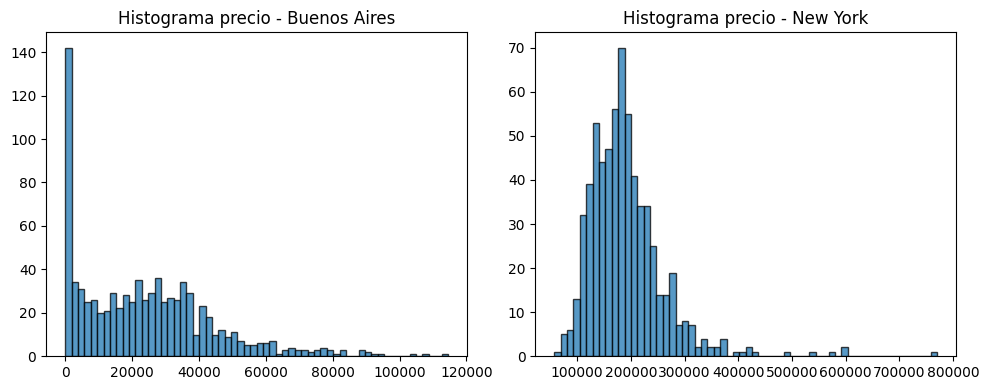

In [361]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(preciosBA, bins=60, edgecolor="black", alpha=0.75)
axes[0].set_title("Histograma precio - Buenos Aires")
axes[1].hist(preciosNY, bins=60, edgecolor="black", alpha=0.75)
axes[1].set_title("Histograma precio - New York")

plt.tight_layout()
plt.show()


Buenos Aires' histogram exhibits a concentration of low values that deviate from the main distribution, it makes no sense that the price of some houses are near 0. As a result, it will be necessary to apply transformations or adjustments to ensure that the model can more accurately learn the underlying relationships.

Threshold Buenos Aires: 3469.419593678956


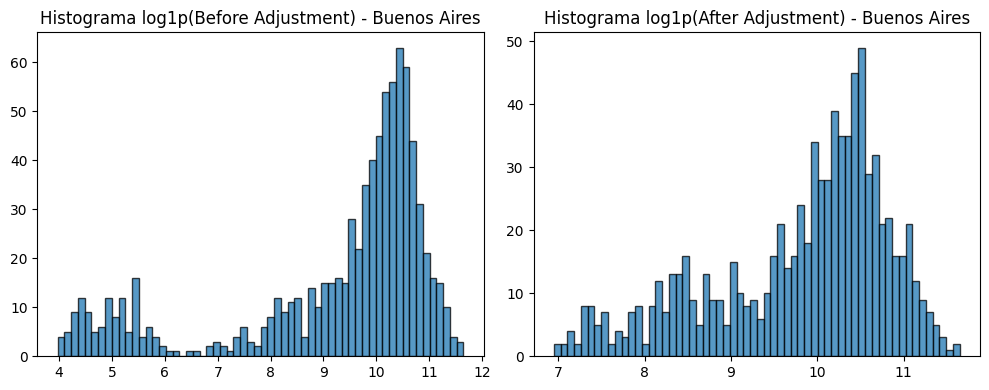

In [362]:
old_data = data_train.copy()

thresholdBA = choose_thresholds(data_train)
print(f"Threshold Buenos Aires: {thresholdBA}")

data_train = adjust_low_prices(data_train, thresholdBA, factorBA=20)
data_test = adjust_low_prices(data_test, thresholdBA, factorBA=20)

pricesBA = data_train[data_train["lat"] < 0]["precio"]
old_pricesBA = old_data[old_data["lat"] < 0]["precio"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(np.log1p(old_pricesBA), bins=60, edgecolor="black", alpha=0.75)
axes[0].set_title("Histograma log1p(Before Adjustment) - Buenos Aires")
axes[1].hist(np.log1p(pricesBA), bins=60, edgecolor="black", alpha=0.75)
axes[1].set_title("Histograma log1p(After Adjustment) - Buenos Aires")
plt.tight_layout()
plt.show()

After adjusting the near-zero price values in the Buenos Aires dataset, the log-transformed histogram exhibits a much smoother and more regular shape, closer to a normal distribution. This improvement reduces distortion in the data and allows the model to better capture underlying patterns, ultimately leading to more reliable price predictions.

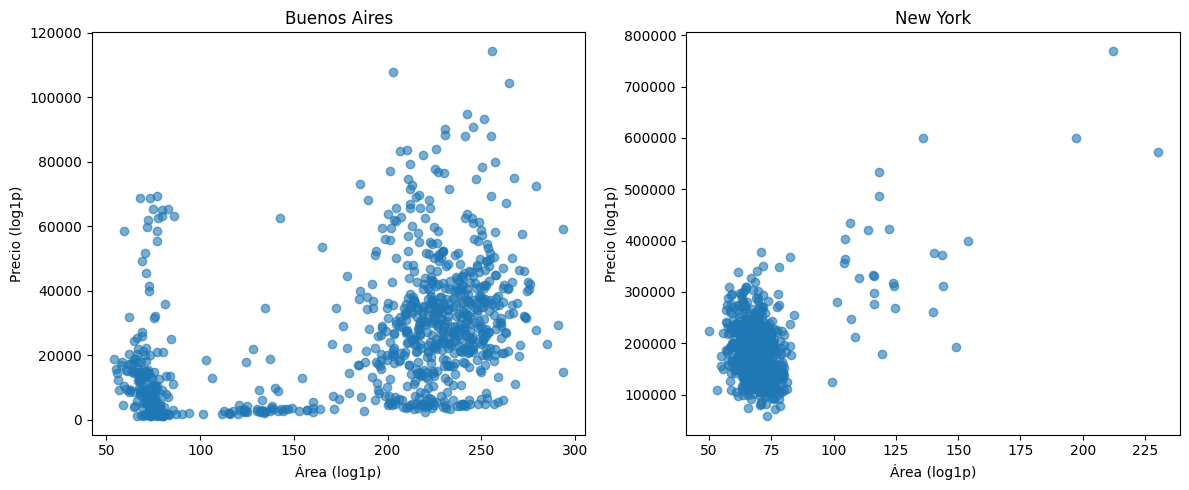

In [363]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(areasBA, pricesBA, alpha=0.6)
axes[0].set_title("Buenos Aires")
axes[0].set_xlabel("Área (log1p)")
axes[0].set_ylabel("Precio (log1p)")
axes[1].scatter(areasNY, preciosNY, alpha=0.6)
axes[1].set_title("New York")
axes[1].set_xlabel("Área (log1p)")
axes[1].set_ylabel("Precio (log1p)")

plt.tight_layout()
plt.show()

The relationship between area and price differs between Buenos Aires and New York. In Buenos Aires, the data is highly dispersed, showing no clear linear pattern. This suggests that area alone is not a strong predictor of price, likely due to the presence of different property types. In contrast, New York shows a more concentrated distribution with a clearer positive relationship between area and price. Overall, this highlights the importance of including location as a key variable in the model.

In [364]:
features = ["precio", "Área", "metros_cubiertos", "ambientes", "pisos", "lat", "lon", "edad"]
data_train = one_hot_encoder_tipo(data_train)
data_test = one_hot_encoder_tipo(data_test)

train_set, val_set = split_data(data_train.copy())

data_train.to_csv("../data/processed/casas_dev_processed.csv", index=False)
data_test.to_csv("../data/processed/casas_test_processed.csv", index=False)

train_ba = train_set[train_set["lat"] < 0]
train_ny = train_set[train_set["lat"] > 0]
val_ba = val_set[val_set["lat"] < 0]
val_ny = val_set[val_set["lat"] > 0]
test_ba = data_test[data_test["lat"] < 0]
test_ny = data_test[data_test["lat"] > 0]

train_ba_norm, statistics_ba = normalize_train(train_ba.copy(), features)
train_ny_norm, statistics_ny = normalize_train(train_ny.copy(), features)

val_ba_norm = normalize_test(val_ba.copy(), features, statistics_ba)
val_ny_norm = normalize_test(val_ny.copy(), features, statistics_ny)

test_ba_norm = normalize_test(test_ba.copy(), features, statistics_ba)
test_ny_norm = normalize_test(test_ny.copy(), features, statistics_ny)

data_train_ba = pd.concat([train_ba, val_ba])
data_train_ny = pd.concat([train_ny, val_ny])

data_train_ba_norm = pd.concat([train_ba_norm, val_ba_norm])
data_train_ny_norm = pd.concat([train_ny_norm, val_ny_norm])

In [365]:
city_datas = [("Buenos Aires", data_train_ba_norm), ("Nueva York", data_train_ny_norm)]

for ciudad, data in city_datas:
    print(f"\n{'='*40}\n{ciudad}\n{'='*40}")
    
    # One feature
    X = data[["Área"]]
    y = data["precio"]

    model = LinearRegression(X, y)
    weights1 = model.pseudo_inverse()
    weights2 = model.gradient_descent()

    print("-- One feature --")
    print("Weights from Pseudo-inverse:\n", weights1)
    print("Weights from Gradient Descent:\n", weights2)
    model.print_coefficients()

    # Multiple features
    X = data[["Área", "ambientes", "metros_cubiertos", "edad"]]
    y = data["precio"]

    model = LinearRegression(X, y)
    weights1 = model.pseudo_inverse()
    weights2 = model.gradient_descent()

    print("-- Multiple features --")
    print("Weights from Pseudo-inverse:\n", weights1)
    print("Weights from Gradient Descent:\n", weights2)
    model.print_coefficients()


Buenos Aires
-- One feature --
Weights from Pseudo-inverse:
 [0.00742092 0.40974184]
Weights from Gradient Descent:
 [0.00742093 0.40974182]
bias: optimum weight = 0.007420926961869868
Área: optimum weight = 0.4097418218652492
-- Multiple features --
Weights from Pseudo-inverse:
 [ 0.00354742  0.31512798 -0.04281958 -0.05432726  0.26368427]
Weights from Gradient Descent:
 [ 0.00354739  0.31512512 -0.04282023 -0.05432497  0.26368458]
bias: optimum weight = 0.0035473923878138066
Área: optimum weight = 0.3151251208960105
ambientes: optimum weight = -0.04282023065169753
metros_cubiertos: optimum weight = -0.05432496634884161
edad: optimum weight = 0.2636845822368913

Nueva York
-- One feature --
Weights from Pseudo-inverse:
 [-0.01171984  0.54000763]
Weights from Gradient Descent:
 [-0.01171985  0.54000727]
bias: optimum weight = -0.011719853171899235
Área: optimum weight = 0.5400072694071039
-- Multiple features --
Weights from Pseudo-inverse:
 [-0.00615029  1.33771761  0.04937207 -0.854

The weights obtained using both methods are nearly identical, indicating that the implementation is consistent and correctly converges to the optimal solution. This behavior is observed in both the single-feature and multi-feature cases, confirming that the model generalizes properly across different input dimensions. Additionally, the agreement between the pseudo-inverse solution and gradient descent demonstrates that the optimization procedure has been implemented correctly and is able to reach the global minimum of the cost function.

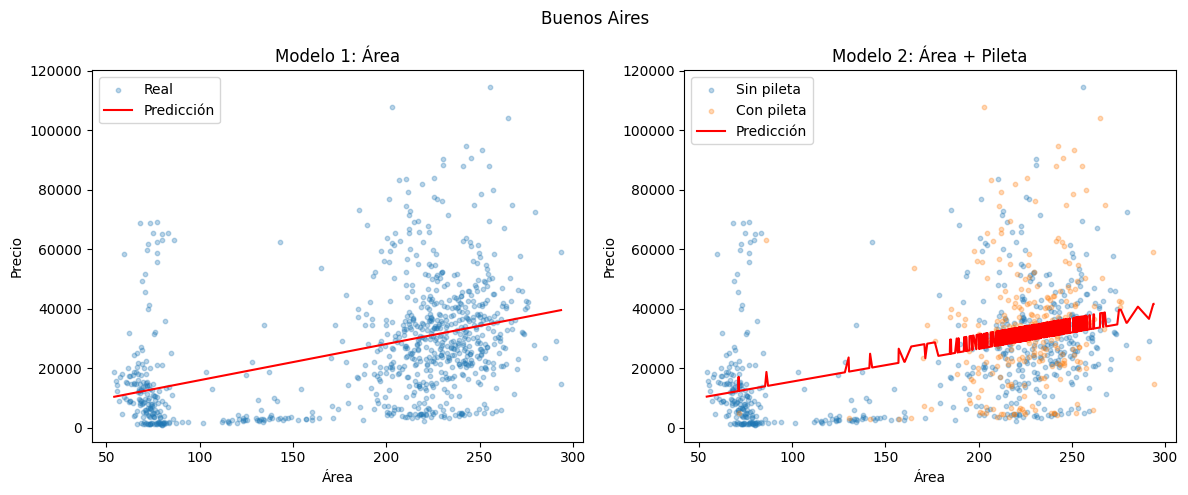

Nueva York: 'pileta' is always 0


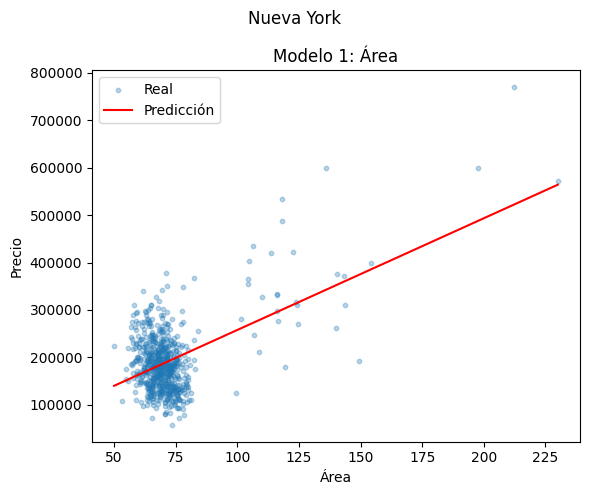

In [366]:
city_datas_stats = [("Buenos Aires", data_train_ba_norm, statistics_ba), ("Nueva York", data_train_ny_norm, statistics_ny)]

for ciudad, data, stats in city_datas_stats:
    data["pileta"] = data["pileta"].astype(int)

    M1 = LinearRegression(data[["Área"]], data["precio"])
    M1.pseudo_inverse()

    use_M2 = data["pileta"].nunique() > 1

    if use_M2:
        M2 = LinearRegression(data[["Área", "pileta"]], data["precio"])
        M2.pseudo_inverse()
        X2_real, y_real2, y_pred2 = denormalize_dataset(M2, stats)
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    else:
        print(f"{ciudad}: 'pileta' is always 0")
        fig, axes = plt.subplots(1, 1, figsize=(6, 5))
        axes = [axes]

    fig.suptitle(ciudad)

    # ---- MODEL 1 ----
    X1_real, y_real1, y_pred1 = denormalize_dataset(M1, stats)

    sort_idx1 = np.argsort(X1_real["Área"])
    axes[0].scatter(X1_real["Área"], y_real1, alpha=0.3, s=10, label="Real")
    axes[0].plot(X1_real["Área"][sort_idx1], y_pred1[sort_idx1], color="red", label="Predicción")
    axes[0].set_title("Modelo 1: Área")
    axes[0].set_xlabel("Área")
    axes[0].set_ylabel("Precio")
    axes[0].legend()

    # ---- MODEL 2  ----
    if use_M2:
        sort_idx2 = np.argsort(X2_real["Área"])
        sin_pileta = X2_real["pileta"] == 0
        con_pileta = X2_real["pileta"] == 1

        axes[1].scatter(X2_real["Área"][sin_pileta], y_real2[sin_pileta], alpha=0.3, s=10, label="Sin pileta")
        axes[1].scatter(X2_real["Área"][con_pileta], y_real2[con_pileta], alpha=0.3, s=10, label="Con pileta")
        axes[1].plot(X2_real["Área"][sort_idx2], y_pred2[sort_idx2], color="red", label="Predicción")

        axes[1].set_title("Modelo 2: Área + Pileta")
        axes[1].set_xlabel("Área")
        axes[1].set_ylabel("Precio")
        axes[1].legend()

    plt.tight_layout()
    plt.show()



As New York properties are primarily apartments and penthouses, which do not include pools, the analysis is conducted exclusively on housing data from Buenos Aires.
The model suggests that having a pool is associated with a slight increase in property prices. However, this effect appears to be relatively weak and not statistically dominant. The dispersion observed in the data indicates that the presence of a pool is not a key determinant of price. In fact, there are multiple cases where houses with a pool and similar area to those without one are priced equally or even lower. This overlap highlights that other variables play a much more significant role in explaining price variation. So, while a pool may add some marginal value, it does not appear to be a decisive factor in property valuation within this dataset.

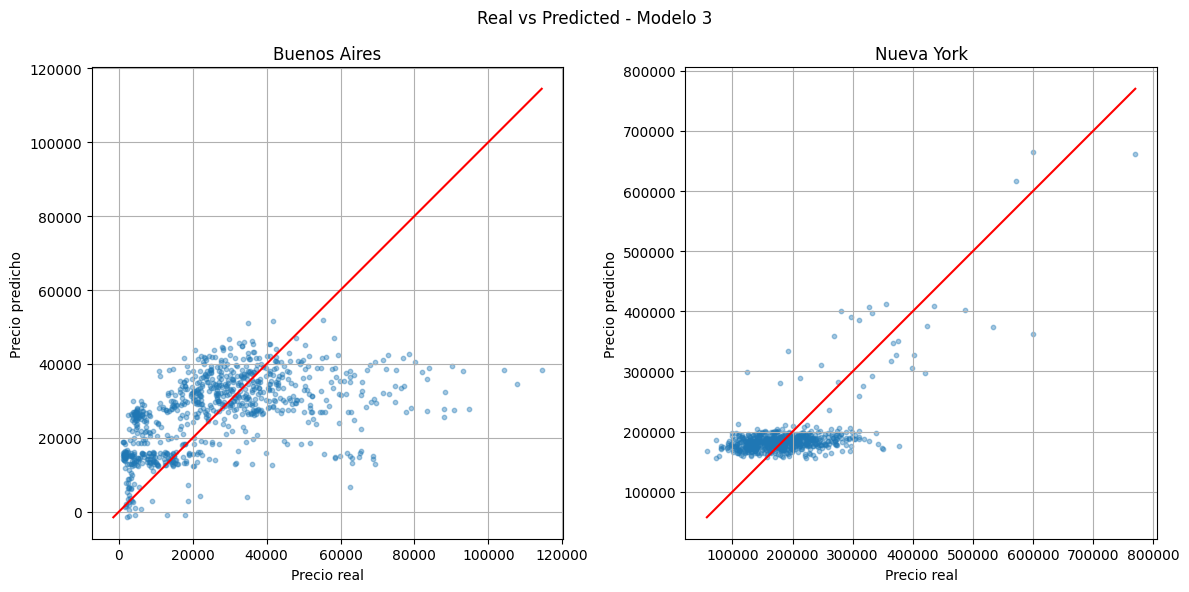

In [367]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
i = 0

for ciudad, data, stats in city_datas_stats:

    X3 = data[[
        "Área", "ambientes", "metros_cubiertos", 
        "edad", "pisos",
        "tipo_casa", "tipo_depto"
    ]]
    y = data["precio"]

    M3 = LinearRegression(X3, y)
    M3.pseudo_inverse()

    X3_real, y3_real, y3_pred = denormalize_dataset(M3, stats)

    ax = axes[i]

    ax.scatter(y3_real, y3_pred, alpha=0.4, s=10)

    min_val = min(y3_real.min(), y3_pred.min())
    max_val = max(y3_real.max(), y3_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], color="red")

    ax.set_title(f"{ciudad}")
    ax.set_xlabel("Precio real")
    ax.set_ylabel("Precio predicho")
    ax.grid(True)

    i += 1 

plt.suptitle("Real vs Predicted - Modelo 3")
plt.tight_layout()
plt.show()




bias: optimum weight = 2.175126398440419e-15
Área: optimum weight = 1.8105700954065265
ambientes: optimum weight = 0.05016734366913884
metros_cubiertos: optimum weight = -0.2821342871047069
edad: optimum weight = 0.6273750065471057
pisos: optimum weight = -0.41407747504596343
tipo_casa: optimum weight = 0.8342314273337132
tipo_depto: optimum weight = 0.10231887117659573
ambientes_por_piso: optimum weight = -0.03749842286690541
area_por_piso: optimum weight = -0.17208834006328178
area_por_ambiente: optimum weight = 0.03134530004820202
ratio_cubierto: optimum weight = 0.38015465252393843
edad_cuadarada: optimum weight = -0.30266710692743465
Área^2: optimum weight = -3.2641841749511533
Área^3: optimum weight = 1.8630450739626516
metros_cubiertos^2: optimum weight = -0.033343622837919466
bias: optimum weight = 8.84752340835071e-15
Área: optimum weight = -14.028293282779568
ambientes: optimum weight = 0.4812554576568525
metros_cubiertos: optimum weight = 6.789707013281136
edad: optimum weig

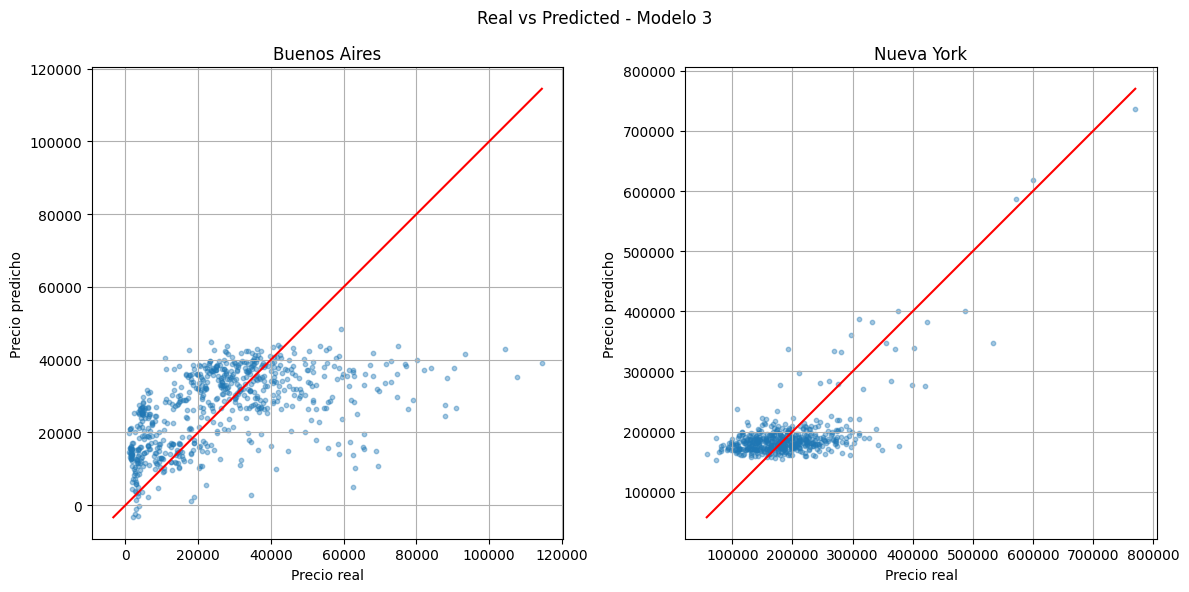

In [368]:
M4_dataBA = train_ba.copy()
M4_dataNY = train_ny.copy()

M4_val_ba = val_ba.copy()
M4_val_ny = val_ny.copy()

for data in [M4_dataBA, M4_dataNY, M4_val_ba, M4_val_ny]:
    data["ambientes_por_piso"] = data["ambientes"] / (data["pisos"])
    data["area_por_piso"] = data["Área"] / (data["pisos"])
    data["area_por_ambiente"] = data["Área"] / (data["ambientes"])
    data["ratio_cubierto"] = data["metros_cubiertos"] / (data["Área"])
    data["edad_cuadarada"] = data["edad"] ** 2
    data["Área^2"] = data["Área"] ** 2
    data["Área^3"] = data["Área"] ** 3
    data["metros_cubiertos^2"] = data["metros_cubiertos"] ** 2

M4_dataBA_norm, statistics_ba = normalize_train(M4_dataBA.copy(), M4_dataBA.columns)
M4_dataNY_norm, statistics_ny = normalize_train(M4_dataNY.copy(), M4_dataNY.columns)

city_datas_stats_M4 = [("Buenos Aires", M4_dataBA_norm, statistics_ba), ("Nueva York", M4_dataNY_norm, statistics_ny)]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
i = 0

for ciudad, data, stats in city_datas_stats_M4:
    X4 = data[[
        "Área", "ambientes", "metros_cubiertos", 
        "edad", "pisos", "tipo_casa", "tipo_depto",
        "ambientes_por_piso", "area_por_piso", "area_por_ambiente",
        "ratio_cubierto", "edad_cuadarada", "Área^2", "Área^3", "metros_cubiertos^2"
    ]]
    y = data["precio"]

    M4 = LinearRegression(X4, y)
    M4.pseudo_inverse()
    M4.print_coefficients()

    X4_real, y4_real, y4_pred = denormalize_dataset(M4, stats)

    ax = axes[i]

    ax.scatter(y4_real, y4_pred, alpha=0.4, s=10)

    min_val = min(y4_real.min(), y4_pred.min())
    max_val = max(y4_real.max(), y4_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], color="red")

    ax.set_title(f"{ciudad}")
    ax.set_xlabel("Precio real")
    ax.set_ylabel("Precio predicho")
    ax.grid(True)

    i += 1 

plt.suptitle("Real vs Predicted - Modelo 3")
plt.tight_layout()
plt.show()



bias: optimum weight = 73.8124409838246
Área: optimum weight = 4.946451295530628e+16
metros_cubiertos: optimum weight = -2.279527967280526e+16
ambientes: optimum weight = -2695082894867953.0
pisos: optimum weight = -3240629900613236.5
pileta: optimum weight = -77532442015064.27
lat: optimum weight = 16023237914494.088
lon: optimum weight = 29939917806784.02
edad: optimum weight = 326969925026571.3
tipo_casa: optimum weight = 1890082598013389.8
tipo_depto: optimum weight = 904783999116306.1
area^2: optimum weight = -1.2266524275484371e+17
area^3: optimum weight = 1.0299066570180968e+17
area^4: optimum weight = -3.4562469878051864e+16
cubierto^2: optimum weight = 3.149833494190749e+16
cubierto^3: optimum weight = -7632768598603721.0
ambientes^2: optimum weight = 4050278349503451.5
edad^2: optimum weight = -166717413403843.06
pisos^2: optimum weight = 3126841624295296.5
area_x_cubierto: optimum weight = 7954137727041378.0
area_x_ambientes: optimum weight = 9637686236217182.0
area_x_edad: 

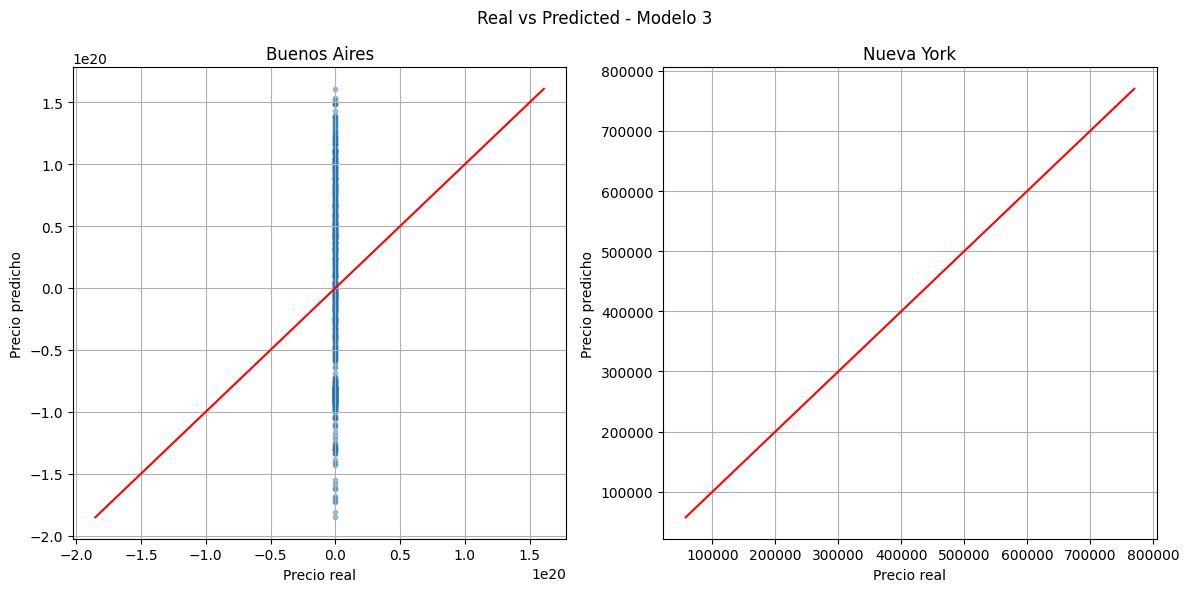

In [369]:
new_dataBA = train_ba.copy()
new_dataNY = train_ny.copy()

new_val_ba = val_ba.copy()
new_val_ny = val_ny.copy()


for data in [new_dataBA, new_dataNY, new_val_ba, new_val_ny]:
    data["area^2"] = data["Área"] ** 2
    data["area^3"] = data["Área"] ** 3
    data["area^4"] = data["Área"] ** 4
    data["cubierto^2"] = data["metros_cubiertos"] ** 2
    data["cubierto^3"] = data["metros_cubiertos"] ** 3
    data["ambientes^2"] = data["ambientes"] ** 2
    data["edad^2"] = data["edad"] ** 2
    data["pisos^2"] = data["pisos"] ** 2
    data["area_x_cubierto"] = data["Área"] * data["metros_cubiertos"]
    data["area_x_ambientes"] = data["Área"] * data["ambientes"]
    data["area_x_edad"] = data["Área"] * data["edad"]
    data["area_x_pisos"] = data["Área"] * data["pisos"]
    data["cubierto_x_ambientes"] = data["metros_cubiertos"] * data["ambientes"]
    data["cubierto_x_edad"] = data["metros_cubiertos"] * data["edad"]
    data["cubierto_x_pisos"] = data["metros_cubiertos"] * data["pisos"]
    data["ambientes_x_edad"] = data["ambientes"] * data["edad"]
    data["ambientes_x_pisos"] = data["ambientes"] * data["pisos"]
    data["area2_x_cubierto"] = (data["Área"] ** 2) * data["metros_cubiertos"]
    data["area2_x_ambientes"] = (data["Área"] ** 2) * data["ambientes"]
    data["cubierto2_x_area"] = (data["metros_cubiertos"] ** 2) * data["Área"]
    data["cubierto2_x_ambientes"] = (data["metros_cubiertos"] ** 2) * data["ambientes"]
    data["ambientes2_x_area"] = (data["ambientes"] ** 2) * data["Área"]
    data["area_por_ambiente"] = data["Área"] / (data["ambientes"] + 1e-5)
    data["area_por_piso"] = data["Área"] / (data["pisos"] + 1e-5)
    data["cubierto_por_area"] = data["metros_cubiertos"] / (data["Área"] + 1e-5)
    data["area_x_ratio"] = data["Área"] * data["cubierto_por_area"]
    data["cubierto_x_ratio"] = data["metros_cubiertos"] * data["cubierto_por_area"]
    data["log_area"] = np.log(np.abs(data["Área"]) + 1)
    data["exp_area"] = np.exp(data["Área"] * 0.1) 
    data["edad3"] = data["edad"] ** 3
    data["area_x_edad2"] = data["Área"] * (data["edad"] ** 2)
    data["cubierto_x_edad2"] = data["metros_cubiertos"] * (data["edad"] ** 2)
    data["area2_x_pisos"] = (data["Área"] ** 2) * data["pisos"]
    data["cubierto2_x_pisos"] = (data["metros_cubiertos"] ** 2) * data["pisos"]
    data["densidad"] = data["ambientes"] / (data["Área"] + 1e-5)
    data["densidad_cubierta"] = data["ambientes"] / (data["metros_cubiertos"] + 1e-5)
    data["area3_x_cubierto"] = (data["Área"] ** 3) * data["metros_cubiertos"]
    data["area_x_cubierto2"] = data["Área"] * (data["metros_cubiertos"] ** 2)
    data["area2_x_edad"] = (data["Área"] ** 2) * data["edad"]
    data["cubierto2_x_edad"] = (data["metros_cubiertos"] ** 2) * data["edad"]
    data["area_x_ambientes2"] = data["Área"] * (data["ambientes"] ** 2)
    data["cubierto_x_ambientes2"] = data["metros_cubiertos"] * (data["ambientes"] ** 2)
    data["area_x_edad_x_pisos"] = data["Área"] * data["edad"] * data["pisos"]
    data["cubierto_x_edad_x_pisos"] = data["metros_cubiertos"] * data["edad"] * data["pisos"]
    data["sqrt_area"] = np.sqrt(np.abs(data["Área"]) + 1e-5)
    data["sqrt_cubierto"] = np.sqrt(np.abs(data["metros_cubiertos"]) + 1e-5)
    data["inv_area"] = 1 / (np.abs(data["Área"]) + 1e-5)
    data["inv_cubierto"] = 1 / (np.abs(data["metros_cubiertos"]) + 1e-5)
    data["area_x_cubierto_x_ambientes"] = data["Área"] * data["metros_cubiertos"] * data["ambientes"]

new_dataBA_norm, statistics_ba = normalize_train(new_dataBA.copy(), new_dataBA.columns)
new_dataNY_norm, statistics_ny = normalize_train(new_dataNY.copy(), new_dataNY.columns)

features = [column for column in new_dataBA.columns]
city_datas_stats = [("Buenos Aires", new_dataBA_norm, statistics_ba), ("Nueva York", new_dataNY_norm, statistics_ny)]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
i = 0

for ciudad, data, stats in city_datas_stats:
    X5 = data[[feature for feature in features if feature != "precio"]]
    y = data["precio"]

    M5 = LinearRegression(X5, y)
    M5.pseudo_inverse()
    M5.print_coefficients()


    X5_real, y5_real, y5_pred = denormalize_dataset(M5, stats)

    ax = axes[i]

    ax.scatter(y5_real, y5_pred, alpha=0.4, s=10)

    min_val = min(y5_real.min(), y5_pred.min())
    max_val = max(y5_real.max(), y5_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], color="red")

    ax.set_title(f"{ciudad}")
    ax.set_xlabel("Precio real")
    ax.set_ylabel("Precio predicho")
    ax.grid(True)

    i += 1 

plt.suptitle("Real vs Predicted - Modelo 3")
plt.tight_layout()
plt.show()

<function identity at 0x00000215655868E0>


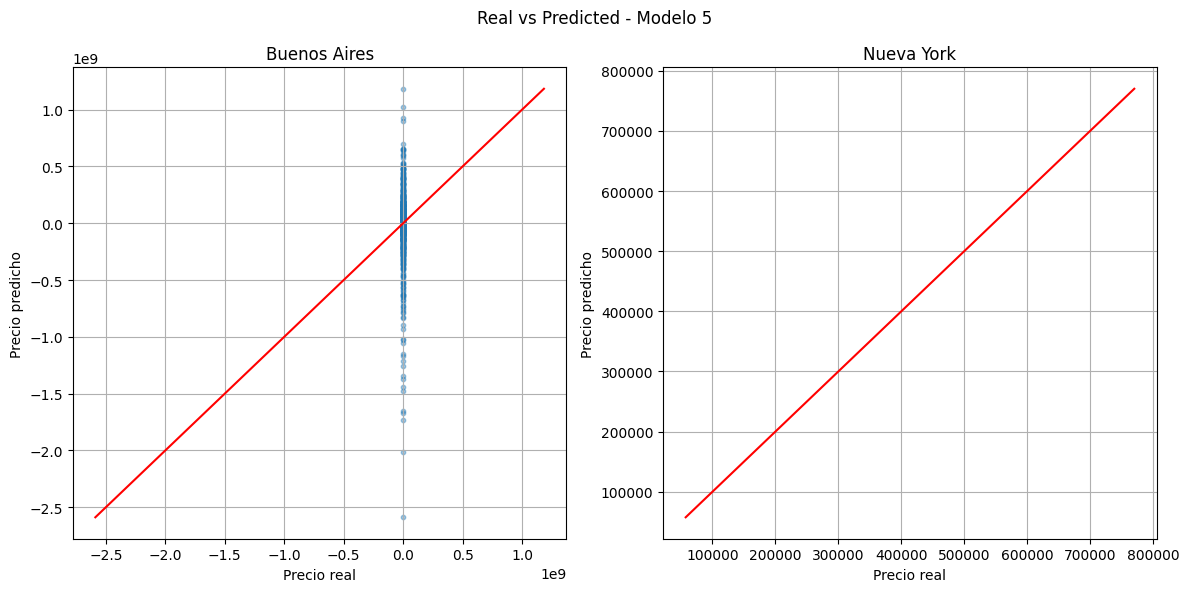

In [370]:
new_dataBA = train_ba.copy()
new_dataNY = train_ny.copy()

print(np.identity)
# 1. Normalizar primero las features base
base_features = [col for col in train_ba.columns if col != "precio"]
new_dataBA_norm, statistics_ba = normalize_train(new_dataBA.copy(), base_features + ["precio"])
new_dataNY_norm, statistics_ny = normalize_train(new_dataNY.copy(), base_features + ["precio"])

# 2. Crear features polinomiales sobre datos normalizados
for data in [new_dataBA_norm, new_dataNY_norm]:
    data["area^2"] = data["Área"] ** 2
    data["area^3"] = data["Área"] ** 3
    data["area^4"] = data["Área"] ** 4
    data["cubierto^2"] = data["metros_cubiertos"] ** 2
    data["cubierto^3"] = data["metros_cubiertos"] ** 3
    data["ambientes^2"] = data["ambientes"] ** 2
    data["edad^2"] = data["edad"] ** 2
    data["pisos^2"] = data["pisos"] ** 2
    data["area_x_cubierto"] = data["Área"] * data["metros_cubiertos"]
    data["area_x_ambientes"] = data["Área"] * data["ambientes"]
    data["area_x_edad"] = data["Área"] * data["edad"]
    data["area_x_pisos"] = data["Área"] * data["pisos"]
    data["cubierto_x_ambientes"] = data["metros_cubiertos"] * data["ambientes"]
    data["cubierto_x_edad"] = data["metros_cubiertos"] * data["edad"]
    data["cubierto_x_pisos"] = data["metros_cubiertos"] * data["pisos"]
    data["ambientes_x_edad"] = data["ambientes"] * data["edad"]
    data["ambientes_x_pisos"] = data["ambientes"] * data["pisos"]
    data["area2_x_cubierto"] = (data["Área"] ** 2) * data["metros_cubiertos"]
    data["area2_x_ambientes"] = (data["Área"] ** 2) * data["ambientes"]
    data["cubierto2_x_area"] = (data["metros_cubiertos"] ** 2) * data["Área"]
    data["cubierto2_x_ambientes"] = (data["metros_cubiertos"] ** 2) * data["ambientes"]
    data["ambientes2_x_area"] = (data["ambientes"] ** 2) * data["Área"]
    data["area_por_ambiente"] = data["Área"] / (data["ambientes"] + 1e-5)
    data["area_por_piso"] = data["Área"] / (data["pisos"] + 1e-5)
    data["cubierto_por_area"] = data["metros_cubiertos"] / (data["Área"] + 1e-5)
    data["area_x_ratio"] = data["Área"] * data["cubierto_por_area"]
    data["cubierto_x_ratio"] = data["metros_cubiertos"] * data["cubierto_por_area"]
    data["log_area"] = np.log(np.abs(data["Área"]) + 1)
    data["edad3"] = data["edad"] ** 3
    data["area_x_edad2"] = data["Área"] * (data["edad"] ** 2)
    data["cubierto_x_edad2"] = data["metros_cubiertos"] * (data["edad"] ** 2)
    data["area2_x_pisos"] = (data["Área"] ** 2) * data["pisos"]
    data["cubierto2_x_pisos"] = (data["metros_cubiertos"] ** 2) * data["pisos"]
    data["densidad"] = data["ambientes"] / (data["Área"] + 1e-5)
    data["densidad_cubierta"] = data["ambientes"] / (data["metros_cubiertos"] + 1e-5)
    data["area3_x_cubierto"] = (data["Área"] ** 3) * data["metros_cubiertos"]
    data["area_x_cubierto2"] = data["Área"] * (data["metros_cubiertos"] ** 2)
    data["area2_x_edad"] = (data["Área"] ** 2) * data["edad"]
    data["cubierto2_x_edad"] = (data["metros_cubiertos"] ** 2) * data["edad"]
    data["area_x_ambientes2"] = data["Área"] * (data["ambientes"] ** 2)
    data["cubierto_x_ambientes2"] = data["metros_cubiertos"] * (data["ambientes"] ** 2)
    data["area_x_edad_x_pisos"] = data["Área"] * data["edad"] * data["pisos"]
    data["cubierto_x_edad_x_pisos"] = data["metros_cubiertos"] * data["edad"] * data["pisos"]
    data["sqrt_area"] = np.sqrt(np.abs(data["Área"]) + 1e-5)
    data["sqrt_cubierto"] = np.sqrt(np.abs(data["metros_cubiertos"]) + 1e-5)
    data["inv_area"] = 1 / (np.abs(data["Área"]) + 1e-5)
    data["inv_cubierto"] = 1 / (np.abs(data["metros_cubiertos"]) + 1e-5)
    data["area_x_cubierto_x_ambientes"] = data["Área"] * data["metros_cubiertos"] * data["ambientes"]

features = [col for col in new_dataBA_norm.columns if col != "precio"]

city_datas_stats = [("Buenos Aires", new_dataBA_norm, statistics_ba), ("Nueva York", new_dataNY_norm, statistics_ny)]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for i, (ciudad, data, stats) in enumerate(city_datas_stats):
    X5 = data[features]
    y = data["precio"]

    M5 = LinearRegression(X5, y)
    M5.pseudo_inverse()

    # solo desnormalizamos precio para el grafico
    mean_y, std_y = stats["precio"]
    y5_real = y * std_y + mean_y
    y5_pred = (M5.X @ M5.coef) * std_y + mean_y

    ax = axes[i]
    ax.scatter(y5_real, y5_pred, alpha=0.4, s=10)
    min_val = min(y5_real.min(), y5_pred.min())
    max_val = max(y5_real.max(), y5_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], color="red")
    ax.set_title(ciudad)
    ax.set_xlabel("Precio real")
    ax.set_ylabel("Precio predicho")
    ax.grid(True)

plt.suptitle("Real vs Predicted - Modelo 5")
plt.tight_layout()
plt.show()

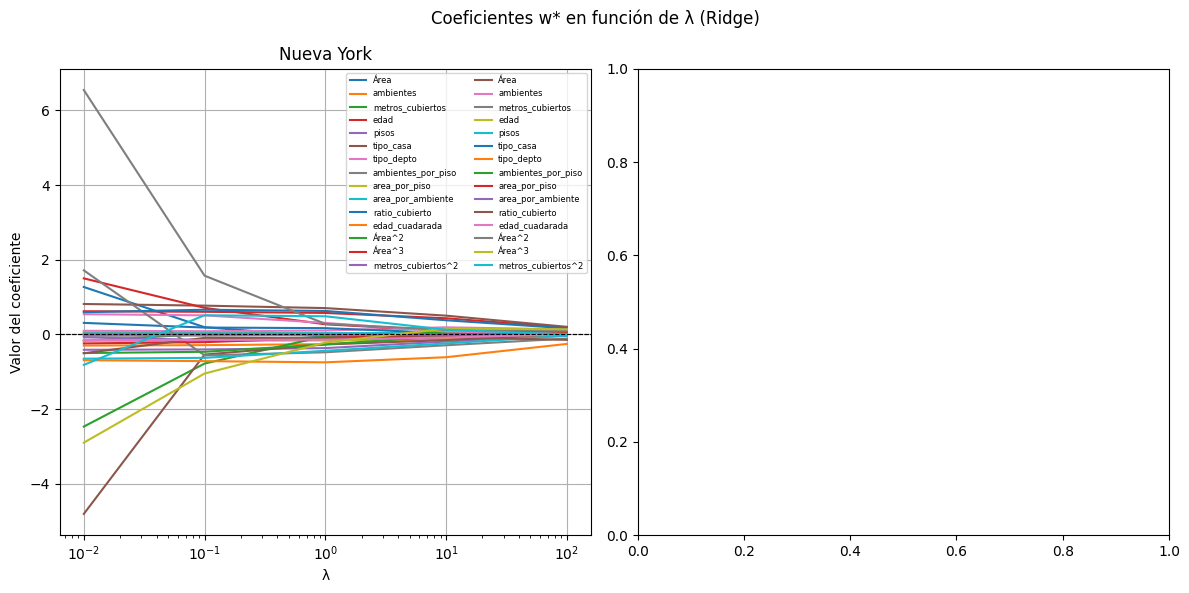

In [ ]:
lambdas = [0.01, 0.1, 1, 10, 100]
featuresM4 = ["Área", "ambientes", "metros_cubiertos", 
        "edad", "pisos", "tipo_casa", "tipo_depto",
        "ambientes_por_piso", "area_por_piso", "area_por_ambiente",
        "ratio_cubierto", "edad_cuadarada", "Área^2", "Área^3", "metros_cubiertos^2"
]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
i = 0

for ciudad, data, stats in city_datas_stats_M4:
    X4 = data[featuresM4]
    y = data["precio"]
    
    coefs_por_lambda = []
    for ridge in lambdas:
        M4 = LinearRegression(X4, y, L2=ridge)
        M4.pseudo_inverse()
        coefs_por_lambda.append(M4.coef[1:]) 

    coefs_por_lambda = np.array(coefs_por_lambda) 

    ax = axes[i]
    for j, feature in enumerate(featuresM4):
        ax.plot(lambdas, coefs_por_lambda[:, j], label=feature)

    ax.set_xscale("log")
    ax.set_xlabel("λ")
    ax.set_ylabel("Valor del coeficiente")
    ax.set_title(ciudad)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.legend(fontsize=6, ncol=2)
    ax.grid(True)

plt.suptitle("Coeficientes w* en función de λ (Ridge)")
plt.tight_layout()
plt.show()


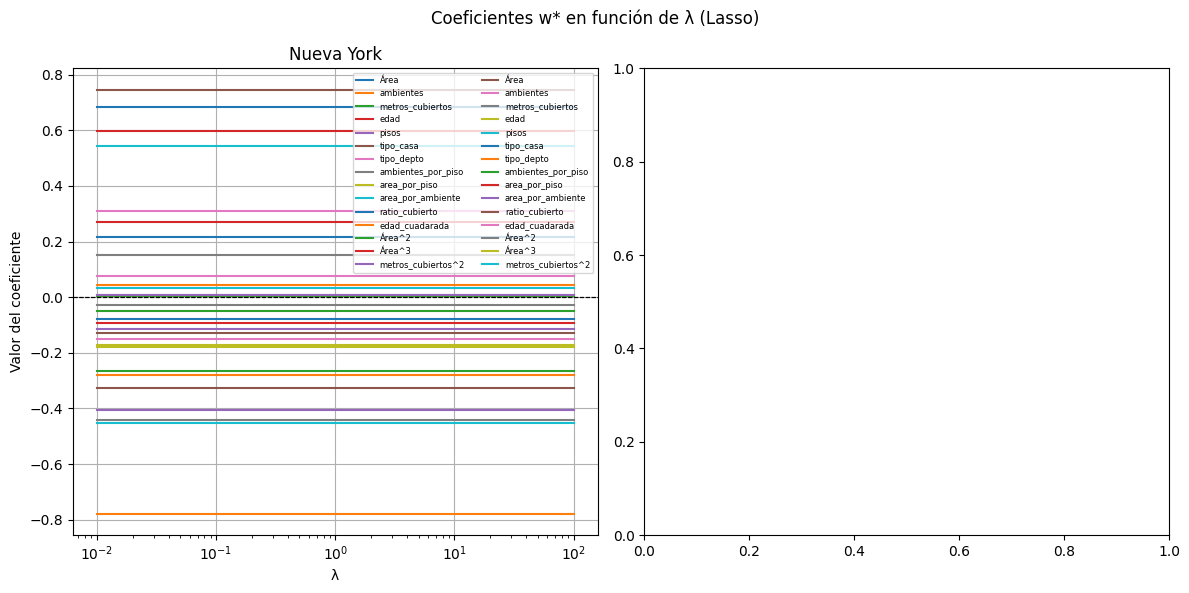

In [378]:
lambdas = [0.01, 0.1, 1, 10, 100]
featuresM4 = ["Área", "ambientes", "metros_cubiertos", 
        "edad", "pisos", "tipo_casa", "tipo_depto",
        "ambientes_por_piso", "area_por_piso", "area_por_ambiente",
        "ratio_cubierto", "edad_cuadarada", "Área^2", "Área^3", "metros_cubiertos^2"
]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
i = 0

for ciudad, data, stats in city_datas_stats_M4:
    X4 = data[featuresM4]
    y = data["precio"]
    
    coefs_por_lambda = []
    for lasso in lambdas:
        M4 = LinearRegression(X4, y, L1=lasso)
        M4.gradient_descent()
        coefs_por_lambda.append(M4.coef[1:]) 

    coefs_por_lambda = np.array(coefs_por_lambda) 

    ax = axes[i]
    for j, feature in enumerate(featuresM4):
        ax.plot(lambdas, coefs_por_lambda[:, j], label=feature)

    ax.set_xscale("log")
    ax.set_xlabel("λ")
    ax.set_ylabel("Valor del coeficiente")
    ax.set_title(ciudad)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.legend(fontsize=6, ncol=2)
    ax.grid(True)

plt.suptitle("Coeficientes w* en función de λ (Lasso)")
plt.tight_layout()
plt.show()